GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | train
5 | fc_hist             | Linear           | 81.0 K | train
6 | feature_mixing_hist | _FeatureMixing   | 47.6 K | train
7 | conditional_mixer   | ModuleList       | 415 K  | train
8 | fc_out              | Linear           | 130    | train
-----------------------------------------------------------------
543 K     Trainable params
0         Non-trainable params
543 K     Total params
2.175     Total estimated model params size (MB)
45        Modules in train

🚀 TSMixer 학습 시작 (7일 장기 예측 모드)...
                                                                           

c:\workspace\wvr\smart_meter_project\wvr_env\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\workspace\wvr\smart_meter_project\wvr_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 29: 100%|██████████| 692/692 [00:43<00:00, 15.75it/s, train_loss=0.0168, val_loss=0.0224]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 692/692 [00:43<00:00, 15.75it/s, train_loss=0.0168, val_loss=0.0224]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



🔮 미래 7일치(336시점) 예측 수행 및 지표 계산 중...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 100.02it/s]

📊 [TSMixer 모델 성능 평가 결과]
 - MAE (평균 오차): 0.1157
 - R² Score (결정계수): 0.3203


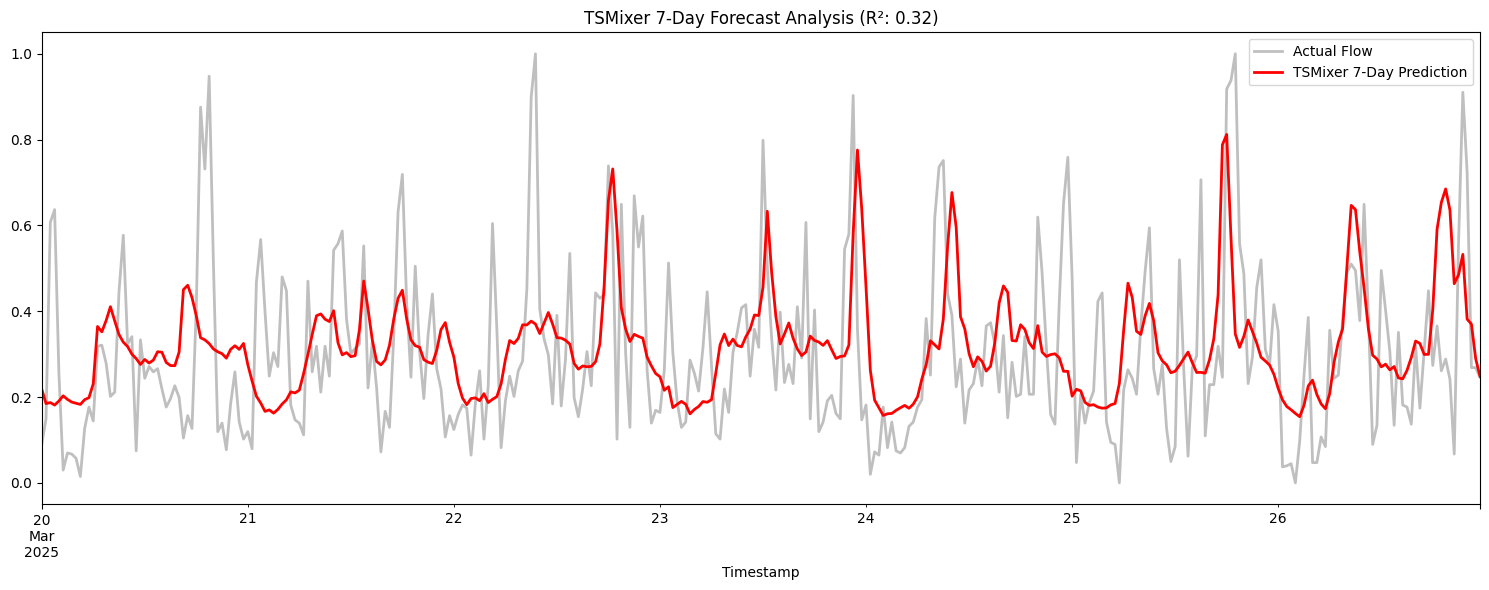

✅ TSMixer 모델 저장 완료: ../models


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import TSMixerModel
from darts.metrics import mae, r2_score
import os

# 1. 통합 전처리된 데이터 로드
input_path = '../data/processed/smart_meter_final.csv'
df = pd.read_csv(input_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Darts 시계열 객체 생성
# (02번 파일에서 이미 리샘플링과 스케일링이 완료된 상태)
series = TimeSeries.from_dataframe(df, 'Timestamp', ['Flow_Instant', 'Pressure'])

# 3. 데이터 분할 (학습/검증)
# 데이터 총 길이를 고려하여 분할 지점 설정
train, val = series.split_before(pd.Timestamp('2025-03-20'))

# 4. TSMixer 모델 설정 (7일 예측 유지 전략)
# 데이터 제약 사항(총 644개 시점)을 고려하여 input_chunk를 240(5일)로 최적화
model = TSMixerModel(
    input_chunk_length=240,  # 과거 약 5일 참조 (48 * 5)
    output_chunk_length=336, # [목표] 미래 7일 예측 (48 * 7)
    n_epochs=30,             # 학습 반복 횟수
    batch_size=16,           # 학습 안정성 확보
    random_state=42,
    force_reset=True
)

# 5. 모델 학습
print("🚀 TSMixer 학습 시작 (7일 장기 예측 모드)...")
model.fit(train, val_series=val)

# 6. 모델 성능 평가 (검증 데이터 기반 예측 수행)
print("🔮 미래 7일치(336시점) 예측 수행 및 지표 계산 중...")
# 검증 데이터의 시작점에서 7일치를 예측
prediction = model.predict(n=336, series=train)

# 성능 지표 산출
ts_mae = mae(val, prediction)
ts_r2 = r2_score(val, prediction)

print(f"\n📊 [TSMixer 모델 성능 평가 결과]")
print(f" - MAE (평균 오차): {ts_mae:.4f}")
print(f" - R² Score (결정계수): {ts_r2:.4f}")

# 7. 결과 시각화
plt.figure(figsize=(15, 6))
# 실제값(전체 중 일부)과 예측값 비교
val['Flow_Instant'][:336].plot(label='Actual Flow', alpha=0.5, color='gray')
prediction['Flow_Instant'].plot(label='TSMixer 7-Day Prediction', color='red', lw=2)
plt.title(f"TSMixer 7-Day Forecast Analysis (R²: {ts_r2:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

# 8. 모델 저장
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)
model.save(os.path.join(model_dir, "tsmixer_model.pth.tar"))
print(f"✅ TSMixer 모델 저장 완료: {model_dir}")
